In [1]:
#imports important modules
import pandas as pd
import numpy as np
import time

In [2]:
# Load datasets
taxi = pd.read_csv("datasets/taxi.csv") # Load the taxi dataset
retail = pd.read_csv("datasets/retail.csv") # Load the retail dataset
tpch = pd.read_csv("datasets/tpch_lineitem.csv") # Load the TPC-H lineitem dataset

# Clean missing values
taxi = taxi.dropna()
retail = retail.dropna()
tpch = tpch.dropna()

print("Datasets loaded successfully")

Datasets loaded successfully


In [ ]:
# Define functions for stratified sampling, random sampling, and exact query execution
def run_query(df, dataset_name): # Function to run the query based on the dataset name
    if dataset_name == "taxi":
        return df[df["trip_distance"] > 5]["fare_amount"].mean() # Calculate the average fare amount for trips longer than 5 miles
    
    elif dataset_name == "retail":
        return (df[df["Quantity"] > 5]["Quantity"] * df["UnitPrice"]).mean() # Calculate the average total price for items with quantity greater than 5
    
    elif dataset_name == "tpch":
        return df[df["l_discount"] < 0.05]["l_extendedprice"].mean() # Calculate the average extended price for items with a discount less than 5%

In [ ]:
# Runs the exact query and measure execution time for each dataset
def exact_query(df, dataset_name): # Function to run the exact query and measure execution time
    start = time.time()
    result = run_query(df, dataset_name) # Run the query and store the result
    end = time.time()
    return result, end - start

In [19]:
# Sampling functions for random and stratified sampling
def random_sampling(df, dataset_name, frac, seed):
    sample = df.sample(frac=frac, random_state=seed)
    return run_query(sample, dataset_name)


def stratified_sampling(df, dataset_name, frac, seed):
    strat_col = get_strat_column(dataset_name)
    
    samples = []
    
    for val, group in df.groupby(strat_col):
        n = int(len(group) * frac)
        if n > 0:
            samples.append(group.sample(n=n, random_state=seed))
    
    strat_sample = pd.concat(samples)
    return run_query(strat_sample, dataset_name)

In [22]:
# Main function to run the experiments

TRIALS = 5 # number of repetitions per experiment
SAMPLE_FRACTIONS = [0.01, 0.05, 0.1, 0.25]

def run_experiment(df, dataset_name):
    
    exact_result, exact_time = exact_query(df, dataset_name)
    
    results = []
    
    for frac in SAMPLE_FRACTIONS:
        
        rand_errors = []
        strat_errors = []
        rand_times = []
        strat_times = []
        
        for trial in range(TRIALS):
            
            start = time.time()
            rand_result = random_sampling(df, dataset_name, frac, trial)
            rand_times.append(time.time() - start)
            
            start = time.time()
            strat_result = stratified_sampling(df, dataset_name, frac, trial)
            strat_times.append(time.time() - start)
            
            rand_errors.append(abs(rand_result - exact_result))
            strat_errors.append(abs(strat_result - exact_result))
        
        results.append({
            "dataset": dataset_name,
            "fraction": frac,
            
            "random_error_mean": np.mean(rand_errors),
            "random_error_std": np.std(rand_errors),
            
            "strat_error_mean": np.mean(strat_errors),
            "strat_error_std": np.std(strat_errors),
            
            "random_time_mean": np.mean(rand_times),
            "strat_time_mean": np.mean(strat_times),
            
            "exact_time": exact_time
        })
    
    return results

In [24]:
#rRun for all 3 datasets and collect results
all_results = []

all_results.extend(run_experiment(taxi, "taxi"))
all_results.extend(run_experiment(retail, "retail"))
all_results.extend(run_experiment(tpch, "tpch"))

results_df = pd.DataFrame(all_results)

results_df

,dataset,fraction,random_error_mean,random_error_std,strat_error_mean,strat_error_std,random_time_mean,strat_time_mean,exact_time
0,taxi,0.01,4.568268,2.652478,8.631309,3.174227,0.002539,0.006315,0.001765
1,taxi,0.05,1.516979,1.032597,2.381376,1.477941,0.000775,0.002979,0.001765
2,taxi,0.10,1.508573,0.899400,2.428391,1.798365,0.000735,0.002268,0.001765
3,taxi,0.25,1.239647,0.761839,1.130002,0.805911,0.000698,0.002231,0.001765
4,retail,0.01,170.662938,83.593396,274.638880,145.617165,0.001045,0.002778,0.000727
5,retail,0.05,53.397682,45.350116,99.386348,88.429528,0.001142,0.003266,0.000727
6,retail,0.10,48.131138,24.597873,77.881722,58.346078,0.001283,0.003255,0.000727
7,retail,0.25,34.067432,18.390733,36.357196,27.420818,0.001608,0.004449,0.000727
8,tpch,0.01,1000.160681,548.820038,2072.879805,1110.386786,0.000988,0.003717,0.000524
9,tpch,0.05,401.152977,303.934914,572.696956,286.558124,0.000919,0.004056,0.000524


In [26]:
# Comparsion vs Baseline
# Compare errors across datasets

comparison = results_df[[
    "dataset",
    "fraction",
    "random_error_mean",
    "strat_error_mean",
    "random_time_mean",
    "strat_time_mean"
]].round(4)

comparison

,dataset,fraction,random_error_mean,strat_error_mean,random_time_mean,strat_time_mean
0,taxi,0.01,4.5683,8.6313,0.0025,0.0063
1,taxi,0.05,1.5170,2.3814,0.0008,0.0030
2,taxi,0.10,1.5086,2.4284,0.0007,0.0023
3,taxi,0.25,1.2396,1.1300,0.0007,0.0022
4,retail,0.01,170.6629,274.6389,0.0010,0.0028
5,retail,0.05,53.3977,99.3863,0.0011,0.0033
6,retail,0.10,48.1311,77.8817,0.0013,0.0033
7,retail,0.25,34.0674,36.3572,0.0016,0.0044
8,tpch,0.01,1000.1607,2072.8798,0.0010,0.0037
9,tpch,0.05,401.1530,572.6970,0.0009,0.0041


In [27]:
# Save results to CSV
results_df.to_csv("results.csv", index=False)

print("Results saved as results.csv")

Results saved as results.csv


In [28]:
# Visualization
import matplotlib.pyplot as plt

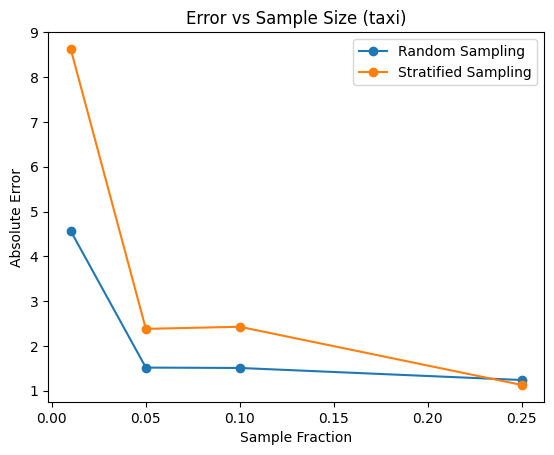

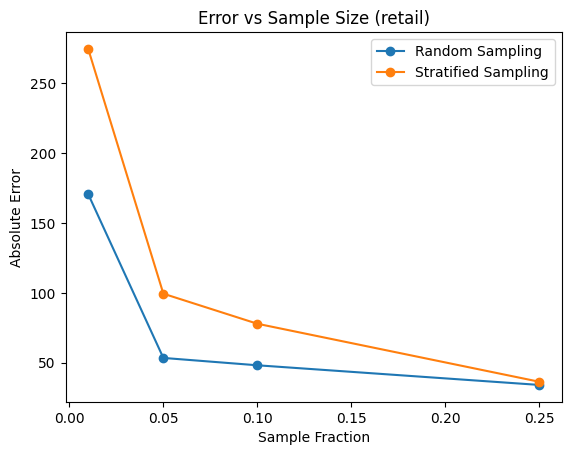

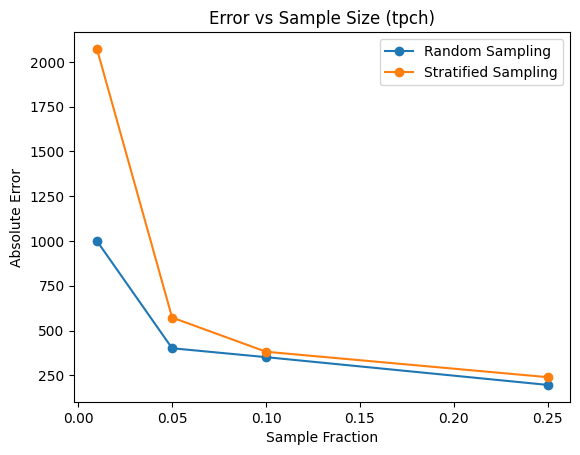

In [30]:
#  Plot error vs sample size for each dataset
# This shows how accuracy improves as sample size increases and how stratified sampling compares to random sampling in terms of error reduction
for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.figure()
    
    plt.plot(df["fraction"], df["random_error_mean"], marker='o', label="Random Sampling")
    plt.plot(df["fraction"], df["strat_error_mean"], marker='o', label="Stratified Sampling")
    
    plt.xlabel("Sample Fraction")
    plt.ylabel("Absolute Error")
    plt.title(f"Error vs Sample Size ({dataset})")
    plt.legend()
    
    plt.show()

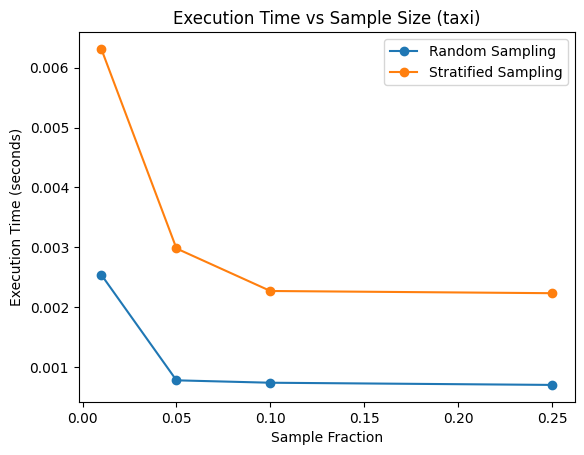

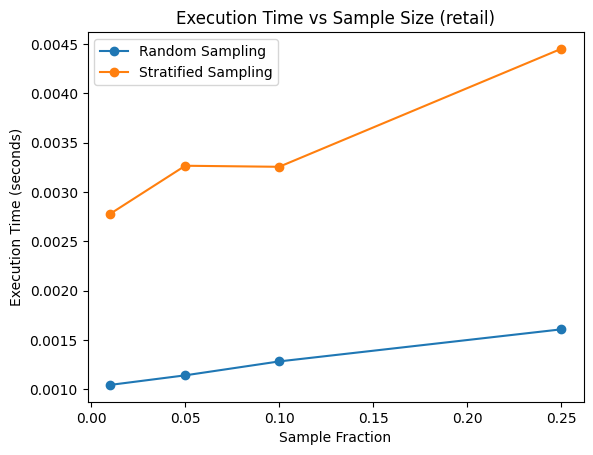

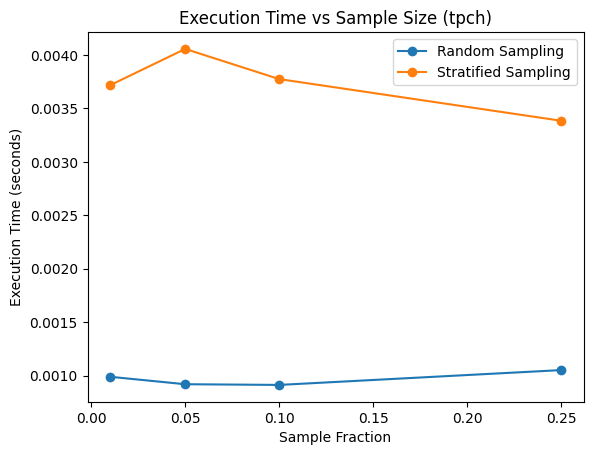

In [32]:
# Plot execution time vs sample size for each dataset
# shows spped difference between random and stratified sampling as sample size increases and how they compare to the exact query execution time
for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.figure()
    
    plt.plot(df["fraction"], df["random_time_mean"], marker='o', label="Random Sampling")
    plt.plot(df["fraction"], df["strat_time_mean"], marker='o', label="Stratified Sampling")
    
    plt.xlabel("Sample Fraction")
    plt.ylabel("Execution Time (seconds)")
    plt.title(f"Execution Time vs Sample Size ({dataset})")
    plt.legend()
    
    plt.show()

<Figure size 640x480 with 0 Axes>

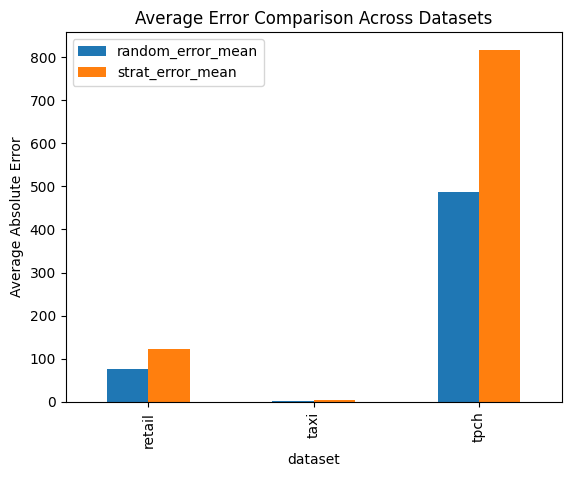

In [34]:
# Bar chart comparing average errors across datasets
plt.figure()

avg_errors = results_df.groupby("dataset")[["random_error_mean", "strat_error_mean"]].mean()

avg_errors.plot(kind="bar")

plt.title("Average Error Comparison Across Datasets")
plt.ylabel("Average Absolute Error")

plt.show()

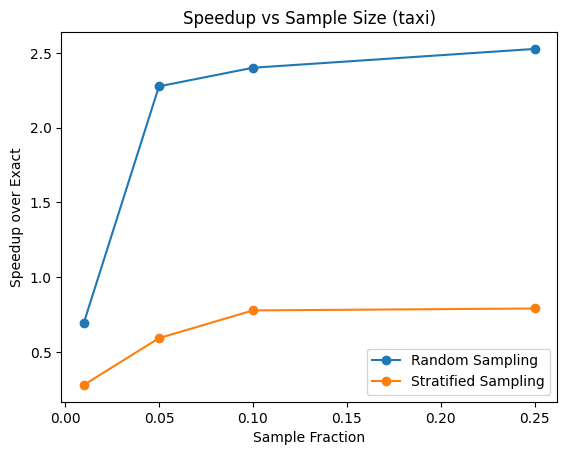

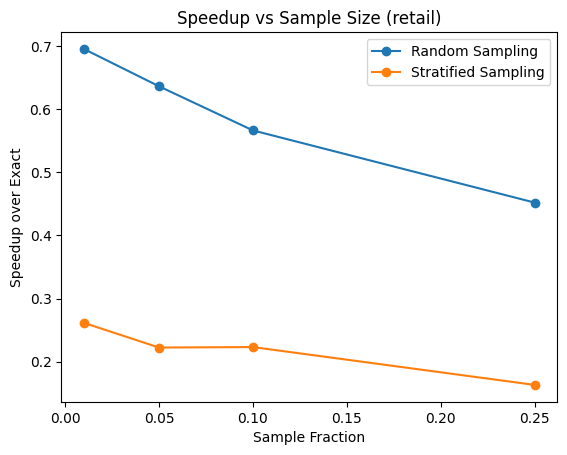

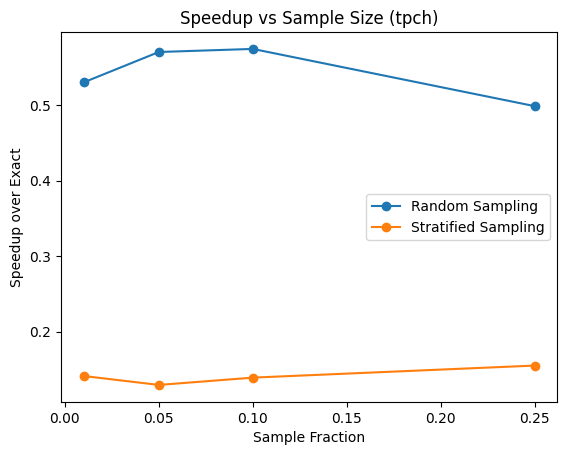

In [36]:
# Chart comparing average execution times across datasets
results_df["random_speedup"] = results_df["exact_time"] / results_df["random_time_mean"]
results_df["strat_speedup"] = results_df["exact_time"] / results_df["strat_time_mean"]

for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.figure()
    
    plt.plot(df["fraction"], df["random_speedup"], marker='o', label="Random Sampling")
    plt.plot(df["fraction"], df["strat_speedup"], marker='o', label="Stratified Sampling")
    
    plt.xlabel("Sample Fraction")
    plt.ylabel("Speedup over Exact")
    plt.title(f"Speedup vs Sample Size ({dataset})")
    plt.legend()
    
    plt.show()

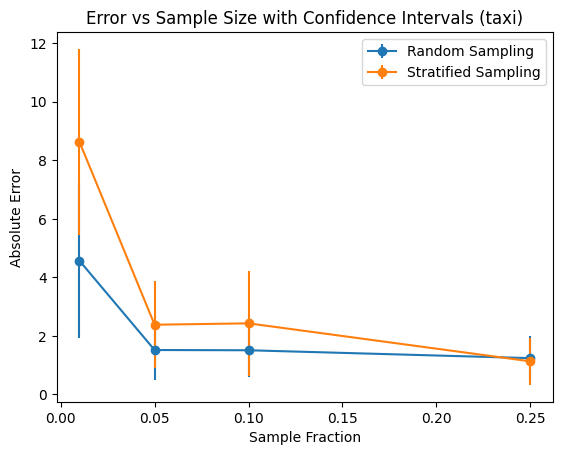

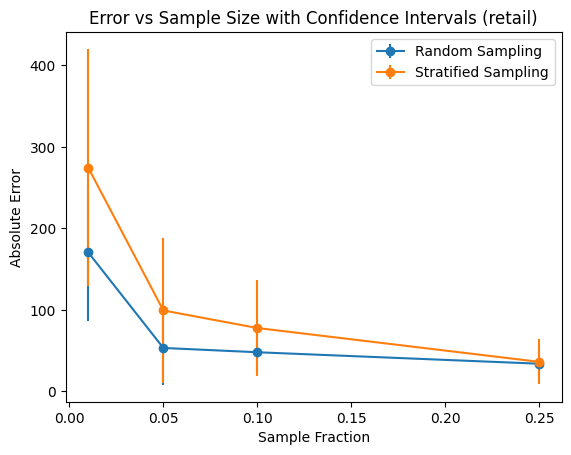

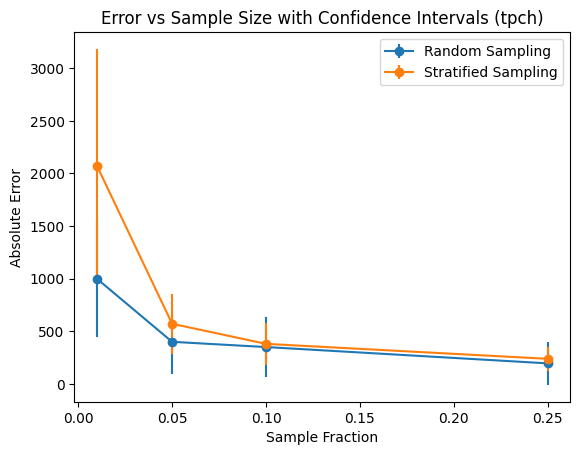

In [37]:
# Plot error vs sample size with confidence intervals for each dataset
for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.figure()
    
    plt.errorbar(
        df["fraction"], 
        df["random_error_mean"], 
        yerr=df["random_error_std"], 
        marker='o', 
        label="Random Sampling"
    )
    
    plt.errorbar(
        df["fraction"], 
        df["strat_error_mean"], 
        yerr=df["strat_error_std"], 
        marker='o', 
        label="Stratified Sampling"
    )
    
    plt.xlabel("Sample Fraction")
    plt.ylabel("Absolute Error")
    plt.title(f"Error vs Sample Size with Confidence Intervals ({dataset})")
    plt.legend()
    
    plt.show()

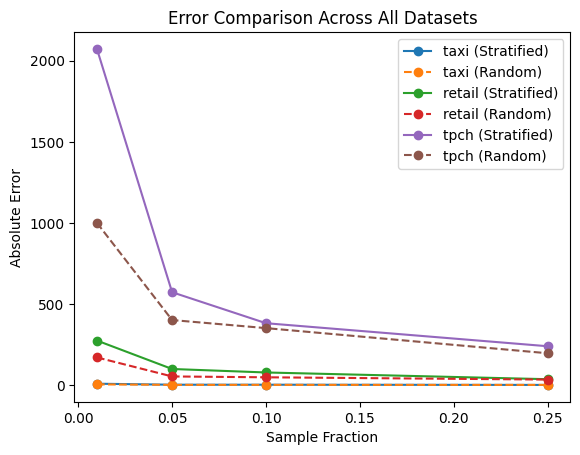

In [38]:
# Combined plot comparing error vs sample size across all datasets
plt.figure()

for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.plot(df["fraction"], df["strat_error_mean"], marker='o', label=f"{dataset} (Stratified)")
    plt.plot(df["fraction"], df["random_error_mean"], linestyle='--', marker='o', label=f"{dataset} (Random)")

plt.xlabel("Sample Fraction")
plt.ylabel("Absolute Error")
plt.title("Error Comparison Across All Datasets")
plt.legend()

plt.show()

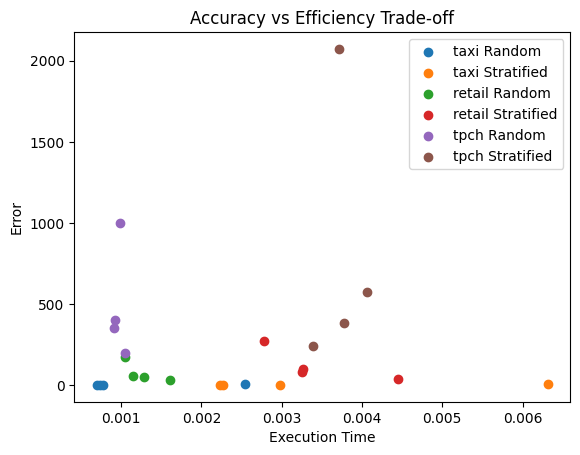

In [39]:
# Combined plot comparing execution time vs sample size across all datasets
plt.figure()

for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.scatter(df["random_time_mean"], df["random_error_mean"], label=f"{dataset} Random")
    plt.scatter(df["strat_time_mean"], df["strat_error_mean"], label=f"{dataset} Stratified")

plt.xlabel("Execution Time")
plt.ylabel("Error")
plt.title("Accuracy vs Efficiency Trade-off")
plt.legend()

plt.show()

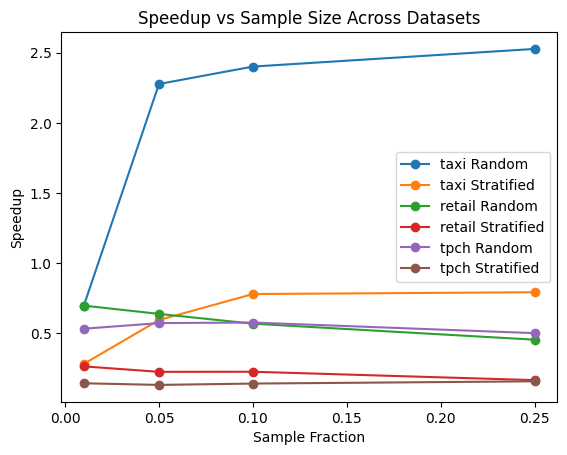

In [40]:
# Chart comparing speedup across datasets
results_df["random_speedup"] = results_df["exact_time"] / results_df["random_time_mean"]
results_df["strat_speedup"] = results_df["exact_time"] / results_df["strat_time_mean"]

plt.figure()

for dataset in results_df["dataset"].unique():
    
    df = results_df[results_df["dataset"] == dataset]
    
    plt.plot(df["fraction"], df["random_speedup"], marker='o', label=f"{dataset} Random")
    plt.plot(df["fraction"], df["strat_speedup"], marker='o', label=f"{dataset} Stratified")

plt.xlabel("Sample Fraction")
plt.ylabel("Speedup")
plt.title("Speedup vs Sample Size Across Datasets")
plt.legend()

plt.show()